# AC Gain Response

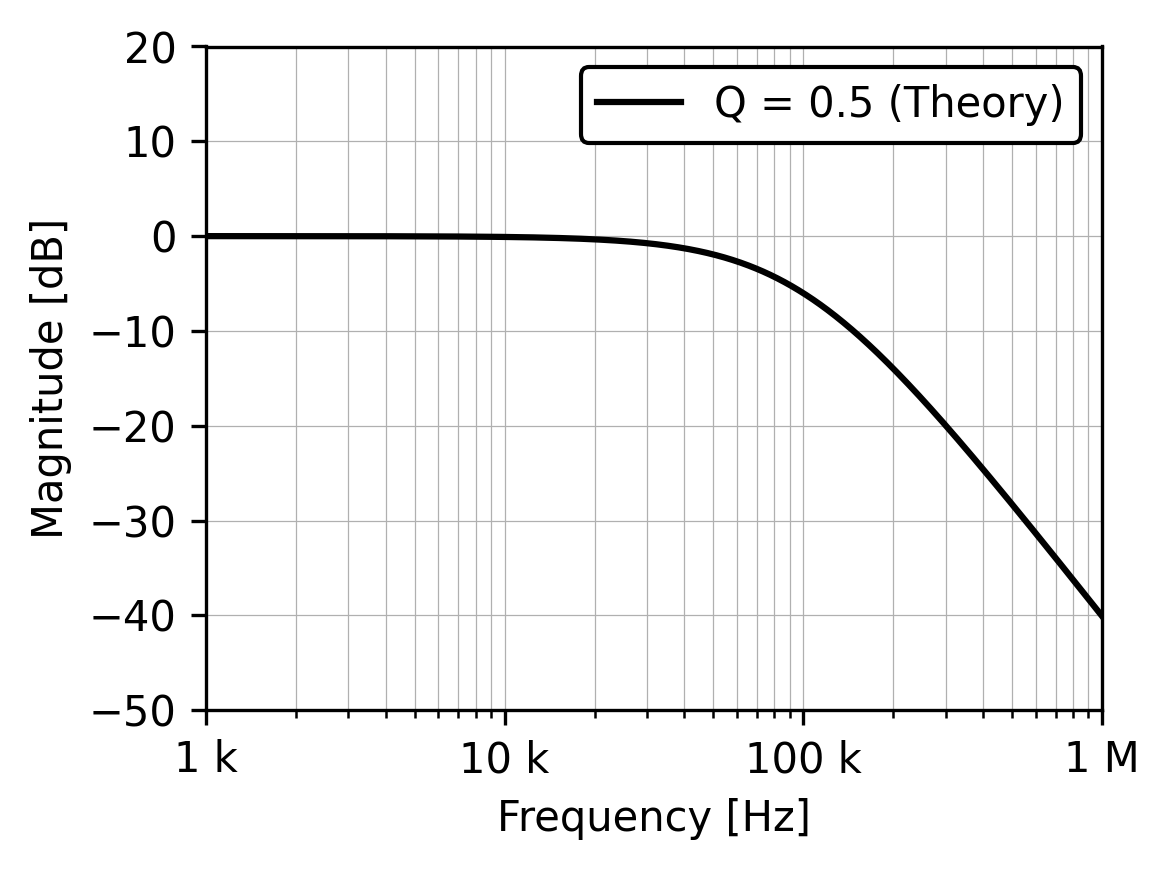

In [14]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy import signal
from matplotlib.ticker import EngFormatter

"""Import simulated data (tsv)"""
# df = pd.read_csv("cad3_data.tsv", sep="\t", header=None)

plt_fmin, plt_fmax, w0 = 1e3, 1e6, 2 * np.pi * 100e3
freq = np.logspace(np.log10(plt_fmin), np.log10(plt_fmax), 1000)

sys = signal.TransferFunction([w0**2], [1, w0/0.5, w0**2])
_, mag, _ = signal.bode(sys, 2 * np.pi * freq)

plt.figure(figsize=(4, 3), dpi=300)
plt.semilogx(freq, mag, "-", color="black", lw=1.5, label="Q = 0.5 (Theory)")

"""Plot simulated data (tsv)"""
# plt.semilogx(df[0], df[1], "--", color="red", lw=1, label="Simulated")

plt.xlabel("Frequency [Hz]"); plt.ylabel("Magnitude [dB]")
plt.xlim(plt_fmin, plt_fmax); plt.ylim(-50, 20)
plt.grid(True, which="both", lw=0.3)
plt.legend(framealpha=1, edgecolor="black")
plt.gca().xaxis.set_major_formatter(EngFormatter(places=0))
plt.tight_layout(); plt.show()

# Step Response

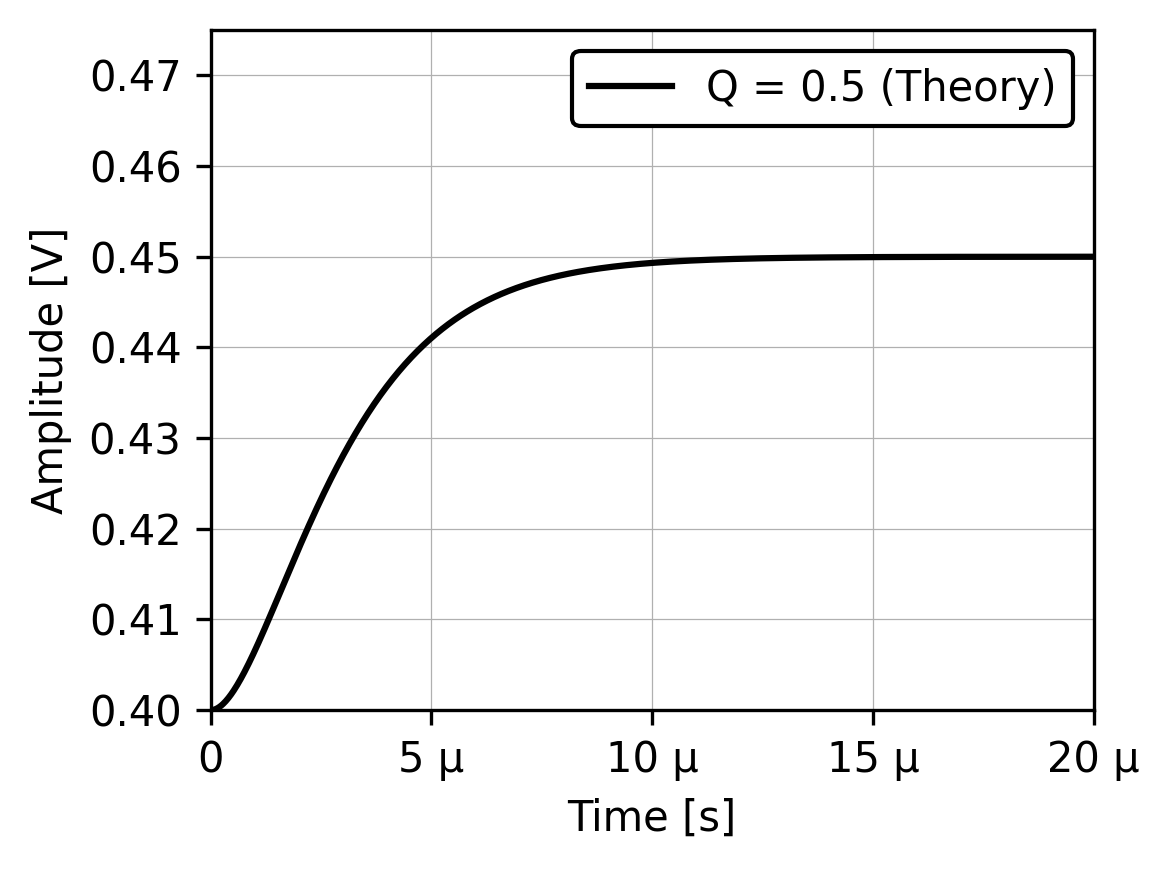

In [13]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy import signal
from matplotlib.ticker import EngFormatter

"""Import simulated data (tsv)"""
# df = pd.read_csv("cad3_tran.tsv", sep="\t", header=None)

plt_tmax, w0 = 20e-6, 2 * np.pi * 100e3
v_step, v_offset = 50e-3, 400e-3			# Adjust these values based on the simulated output
t = np.linspace(0, plt_tmax, 1000)

sys = signal.TransferFunction([w0**2], [1, w0/0.5, w0**2])
_, y = signal.step(sys, T=t)

plt.figure(figsize=(4, 3), dpi=300)
plt.plot(t, v_offset+y*v_step, "-", color="black", lw=1.5, label="Q = 0.5 (Theory)")

"""Plot simulated data (tsv)"""
# plt.plot(df[0], df[2], "--", color="red", lw=1, label="Simulated")

plt.xlabel("Time [s]"); plt.ylabel("Amplitude [V]")
plt.xlim(0, plt_tmax); plt.ylim(v_offset, v_offset+1.5*v_step)
plt.grid(True, lw=0.3)
plt.legend(framealpha=1, edgecolor="black")
plt.gca().xaxis.set_major_formatter(EngFormatter(places=0))
plt.tight_layout(); plt.show()